# Fake news classification

In this task we use Kaggle __[fake news dataset](https://www.kaggle.com/clmentbisaillon/fake-and-real-news-dataset)__ in order to train text classification models to detect fake news from the text and analyze their performances.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wordcloud
import pandas as pd
from nltk.stem.snowball import SnowballStemmer
from nltk import word_tokenize
from nltk.corpus import stopwords
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn import metrics
import re
import string

from sklearn.naive_bayes import MultinomialNB
import tensorflow as tf
from tensorflow.keras import layers
import tensorflow_hub as hub
import tensorflow_text as tf_text

#### Packages required to run this notebook

The install packages a few of which could be explicit but required to run this notebook are enlisted nelow

In [3]:
"""
numpy
matplotlib
pandas
seaborn
wordcloud # for visualization
nltk
scikit-learn
tensorflow
tensorflow-text # An explicit dependency of the preprocessing for BERT inputs
tensorflow-hub
"""

'\nnumpy\nmatplotlib\npandas\nseaborn\nwordcloud # for visualization\nnltk\nscikit-learn\ntensorflow\ntensorflow-text # An explicit dependency of the preprocessing for BERT inputs\ntensorflow-hub\n'

In [4]:
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [5]:
sns.set_theme(style="darkgrid")

## 1. Load data

We have downloaded the data in the local directory. Hence from the local path we load the data and visualize it.

In [8]:
df_real = pd.read_csv("archive/True.csv")
df_fake = pd.read_csv("archive/Fake.csv")

In [9]:
df_real = pd.read_csv("archive/True.csv")
df_fake = pd.read_csv("archive/Fake.csv")

In [10]:
df_real.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [11]:
df_fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


## 2. Create text dataset

We would be using the `title` and `text` fields to create the classification dataset. Atfirst we need to merge the 2 dataframes into a unified dataframe and assign labels to the corresponding rows.

As the task is to detect fake news, we assign class _**1**_ to fake and class _**0**_ to real news.

In [12]:
# Assign class labels
df_fake["label"] = 1
df_real["label"] = 0

# Join the 2 dataframes into a unified dataset
df_dataset = pd.concat([df_fake, df_real], axis=0)
df_dataset

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1
...,...,...,...,...,...
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",0
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",0
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",0
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",0


### 2.1. Analyze class balance

We need to check if the classes `real` and `fake` are balanced in proportion in order for the classification models to be trained nicely without unwanted bias due to significant difference in the number of training examples per class.

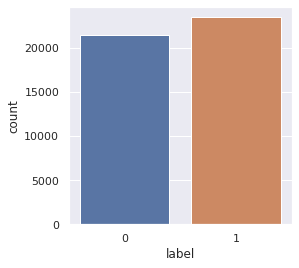

In [13]:
plt.figure(figsize=(4, 4))
sns.countplot(x="label", data=df_dataset)
plt.show()

We notice that the difference is insignificant, which is desired.

### 2.2. Merge the title and text fields

Next we merge the content of the fields `title` and `text` to create the unifield text corpus, over which we will be perform further analysis.

In [14]:
# Text data variable
X_text = df_dataset["title"] + " " + df_dataset["text"]

# Corresponding label variable
y = df_dataset["label"]

X_text

0         Donald Trump Sends Out Embarrassing New Year’...
1         Drunk Bragging Trump Staffer Started Russian ...
2         Sheriff David Clarke Becomes An Internet Joke...
3         Trump Is So Obsessed He Even Has Obama’s Name...
4         Pope Francis Just Called Out Donald Trump Dur...
                               ...                        
21412    'Fully committed' NATO backs new U.S. approach...
21413    LexisNexis withdrew two products from Chinese ...
21414    Minsk cultural hub becomes haven from authorit...
21415    Vatican upbeat on possibility of Pope Francis ...
21416    Indonesia to buy $1.14 billion worth of Russia...
Length: 44898, dtype: object

### 2.3. Data exploration

As an initial basic data exploration step, we visualize most frequently used words in the case of both real and fake news.

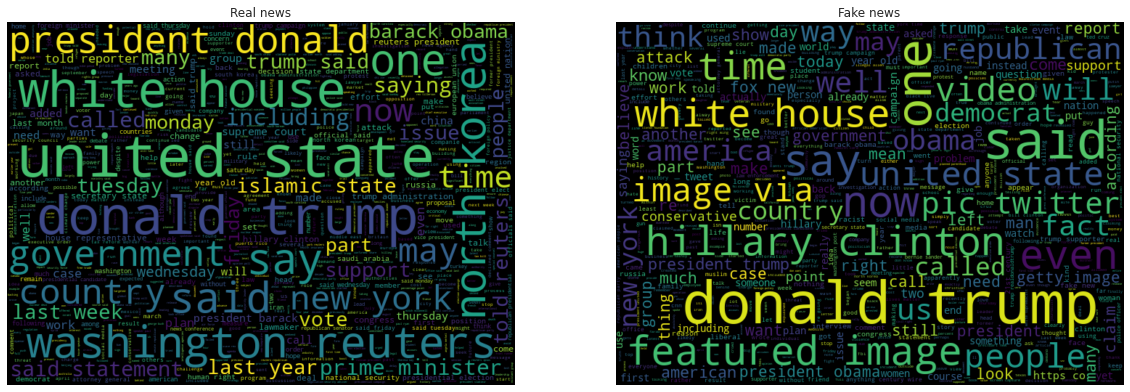

In [15]:
# Generate the wordclouds
wordcloud_real = wordcloud.WordCloud(stopwords=wordcloud.STOPWORDS, max_font_size=80, max_words=5000,
                      width = 700, height = 500,
                      background_color='black').generate(' '.join(txt for txt in df_real["title"]+ " " + df_real["text"]).lower().strip())
wordcloud_fake = wordcloud.WordCloud(stopwords=wordcloud.STOPWORDS, max_font_size=80, max_words=5000,
                      width = 700, height = 500,
                      background_color='black').generate(' '.join(txt for txt in df_fake["title"]+ " " + df_fake["text"]).lower().strip())

# show the wordclouds
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
ax1.imshow(wordcloud_real, interpolation='bilinear')
ax2.imshow(wordcloud_fake, interpolation='bilinear')

ax1.set_title('Real news')
ax2.set_title('Fake news')

ax1.set_axis_off()
ax2.set_axis_off()

We see that simply by means of looking at the frequently used words, nothing much can be distinguished. Much better analysis can be found at the language level.

## 3. Preprocess text dataset

We perform some standard NLP text preprocessing steps which decreases text embedding/ vectorization complexity, which in turn helps the classification process. These steps are 
1. **Text cleaning:** Remove links, special characters etc from the text, which is considered as noise.
2. **Stop words removal:** Remove common English stop words such as 'a', 'and', 'it' etc as they are not useful for statistical text modeling.
2. **Stemming:** Convert the words to its stem by a rule based heuristic process. For example, “cooking,” and “cooked” belong to the same stem of “cook.”

**Note**: The steps of _stopwords removal_ and _stemming_, an impact the meaning of a text significantly and also hinder sequential word ordering, which can implicate the ability of our models to learn the meaning of the text, which might be crucial for classifying a news as fake or real, as sentiment of a text can play role in this task. Therefore, as deep language models like LSTM, transformers can learn from the language sequence, we will not perform these 2 steps for creating word models for DNNs, but only perform for creating heuristical word vector models for baseline classifiers.

### 3.1. Text cleaning

In this step we remove html tags, links, non-ASCII characters, new lines and long white spaces from the text as noise. Also convert the whole text to lower case.

In [16]:
# The text cleaning script
def clean_text(text):
    text = re.sub(r"<.*?>", " ", text) # remove html
    text = re.sub(r"http\S+", " ", text) # remove links
    text = re.sub(r"[^\x00-\x7F]+", " ", text) # remove non-ascii characters
    text = re.sub(r"\n", " ", text) # remove new line
    text = re.sub(r"\s+", " ", text) # remove long whitespaces
    
    text = text.lower().strip() # convert to lower case
    
    return text

In [17]:
# Script to extract only text
def extract_text(text):
    text = re.sub("[^a-zA-Z]", " ", text)
    text = re.sub(r"\s+", " ", text) # remove long whitespaces
    
    return text

In [18]:
X_text = X_text.apply(clean_text)
X_text.values[0] # View the first document after preprocessing

'donald trump sends out embarrassing new year s eve message; this is disturbing donald trump just couldn t wish all americans a happy new year and leave it at that. instead, he had to give a shout out to his enemies, haters and the very dishonest fake news media. the former reality show star had just one job to do and he couldn t do it. as our country rapidly grows stronger and smarter, i want to wish all of my friends, supporters, enemies, haters, and even the very dishonest fake news media, a happy and healthy new year, president angry pants tweeted. 2018 will be a great year for america! as our country rapidly grows stronger and smarter, i want to wish all of my friends, supporters, enemies, haters, and even the very dishonest fake news media, a happy and healthy new year. 2018 will be a great year for america! donald j. trump (@realdonaldtrump) december 31, 2017trump s tweet went down about as welll as you d expect.what kind of president sends a new year s greeting like this despic

### 3.2. Stemming & Stop words removal

We choose _Snowball_ stemmer as it is an advanced version of _Porter_ stemmer. Lancaster stemmer is not used to avoid the possibility of overstemming, as Lancaster stemming algorithm can be overly aggressive.

In [19]:
stemmer = SnowballStemmer("english")

In [20]:
def stem_text(text):
    # Get text only
    text = extract_text(text)
    
    # create word tokens
    text = word_tokenize(text)
    
    # stop words removal
    text = [word for word in text if not word in stopwords.words("english")]
    
    # stemming
    text = [stemmer.stem(word) for word in text]
    text = " ".join(text)
    
    return text

In [21]:
# Create stemmed text
X_stemmed = X_text.apply(stem_text)
X_stemmed

0        donald trump send embarrass new year eve messa...
1        drunk brag trump staffer start russian collus ...
2        sheriff david clark becom internet joke threat...
3        trump obsess even obama name code websit imag ...
4        pope franci call donald trump christma speech ...
                               ...                        
21412    fulli commit nato back new u approach afghanis...
21413    lexisnexi withdrew two product chines market l...
21414    minsk cultur hub becom author minsk reuter sha...
21415    vatican upbeat possibl pope franci visit russi...
21416    indonesia buy billion worth russian jet jakart...
Length: 44898, dtype: object

## 4. Feature engineering

We need to create features from the text, for training the classifiers as raw text can not be used for training. For this purpose we can either create word vector modeling(heuristic approach) such as _count vectorizer_, _tf-tdf_ etc or we can use pretrained word embedding models such as _BERT tokenizer_, _gensim word2vec_ etc. We can also train our own _embedding model_ on this text corpus from scratch while training the classification model.

#### Split stemmed text dataset for TF-IDF vectorization

We split the tf-tdf dataset in _70%-30%_ split ratio for training the classifiers. We make stratified split so that the class labels are evenly distributed accross the train-test split.

In [22]:
X_tfidf_train, X_tfidf_test, y_tfidf_train, y_tfidf_test = train_test_split(X_stemmed.values , y.values, test_size=0.3, 
                                                                            random_state=0, stratify=y)

### 4.1. TF-IDF vectorization

We are going to use _tf-idf_ vectorization technique to to create word vector models, in order to train a baseline machine learning classifier. For computational and memory limitation reason and also to avoid overfitting, we need to reduce feature dimension. Hence, we set _10000_ as the max vocabulary length to be used in tf-tdf vectorization process.

**Note:** In order to prevent _data leakage_, we compute the _tf-tdf_ vectorization parameters on training data only, and then compute the test set vector based on those parameters. The drawback of this approach is that the performance of the classifier trained on this data will be impacted by the _tf-idf_ vectorization performance as well. Still, we accept this drawback, in order to avoid data leak, which seems to be a bigger drawback to judge model performance.

In [23]:
# Max vocabulary length
max_features = 10000

In [24]:
# Tf-idf vectorization on train data
tfidf_vectorizer = TfidfVectorizer(analyzer='word', max_features=max_features, stop_words='english')
X_tfidf_train = tfidf_vectorizer.fit_transform(X_tfidf_train).toarray()

# Tf-idf transform test data
X_tfidf_test = tfidf_vectorizer.transform(X_tfidf_test).toarray()

print(f'TF-TDF train dataset dimension: {X_tfidf_train.shape}')
print(f'TF-TDF test dataset dimension: {X_tfidf_test.shape}')

TF-TDF train dataset dimension: (31428, 10000)
TF-TDF test dataset dimension: (13470, 10000)


#### TF-IDF vector analysis

We can compare cosine similarity between the real and fake news tf-tdf datasets and try to get an idea of a degre of similarity between them. For a better understanding it can be compared with the similarity measure computed among the real corpus and fake corpus within themselves.

We use the test set only for this exercise for memory limitations. As the nature of the similarity should persist in both train and test set, this should not be a problem.

In [25]:
test_tfidf_fake = np.take(X_tfidf_test, np.where(y_tfidf_test == 1), axis=0)[0]
test_tfidf_real = np.take(X_tfidf_test, np.where(y_tfidf_test == 0), axis=0)[0]

cosine_sim_fake_real = cosine_similarity(test_tfidf_fake, test_tfidf_real)
cosine_sim_fake = cosine_similarity(test_tfidf_fake, test_tfidf_fake)
cosine_sim_real = cosine_similarity(test_tfidf_real, test_tfidf_real)

In [26]:
print(f'Mean similarity real vs fake corpus: {cosine_sim_fake_real.mean()}')
print(f'Mean similarity within fake corpus: {cosine_sim_fake.mean()}')
print(f'Mean similarity within real corpus: {cosine_sim_real.mean()}')

Mean similarity real vs fake corpus: 0.030558347918615857
Mean similarity within fake corpus: 0.038385055361523285
Mean similarity within real corpus: 0.04452861897051444


In [ ]:
# Save the vectors locally if required
# np.save('X_tfidf_train.npy', X_tfidf_train)
# np.save('X_tfidf_test.npy', X_tfidf_test)

### 4.2. Trainable Word Embedding

For the purpose of training the Recurrent Neural network model, we are going to create a trainable word embedding layer using a trainable word vectorizer layer, because RNNs are very good sequential models which learns from text sequences. The text corpus will be vectorized by this layer in the network while training.
The maximum vocabulary length is set same as tf-tdf vocabulary length used before, i.e. _10000_. The output sequence length of the embedding is set is set to _512_, which will be length of the output vector.

Sources followed for this part of exercise is [tensorflow text vectorzation tutorial](https://www.tensorflow.org/text/tutorials/text_classification_rnn)

In [28]:
# Sequence length of the embedded vector
seq_len = 512

# The trainable vectorization layer
text_vectorization_layer = layers.experimental.preprocessing.TextVectorization(
    standardize='lower_and_strip_punctuation',
    max_tokens=max_features,
    output_mode='int',
    output_sequence_length=seq_len)

#### Split text dataset for training DNNs

We split the text dataset in _70%-30%_ split ratio for training the RNN. Same as before we make stratified split so that the class labels are evenly distributed accross the train-test split.

In [29]:
X_text_train, X_text_test, y_text_train, y_text_test = train_test_split(X_text.values, y.values, test_size=0.3, 
                                                                            random_state=0, stratify=y)

In [30]:
batch_size = 32

# create the train and validation dataset
train_text_dataset = tf.data.Dataset.from_tensor_slices((X_text_train, y_text_train)).shuffle(5000).batch(batch_size)
val_text_dataset = tf.data.Dataset.from_tensor_slices((X_text_test, y_text_test)).batch(batch_size)

#### Map the vectorization layer to the train text dataset

The vocabulary layer has to be mapped to text-only dataset to create the vocabulary. We do not want the trainable embedding layer have access to the test dataset text. That's why the vocabulary is created on the train corpus.

In [31]:
text_vectorization_layer.adapt(next(iter(train_text_dataset.map(lambda x, y: x))))

### 4.3. Pretrained BERT Word Embedding

For the purpose of finetuning BERT model, we are going to use pretrained BERT text preprocessor embedding model. We pick this model from Tensorflow hub. The embedding will be fine tuned as a layer by our dataset while BERT model training. The input to this layer will be the same text dataset created in the previous section for the trainable word embedding.

In [32]:
# Load pretrained BERT preprocessing model path
bert_preprocess_path_tf_hub = 'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3'

## 5. Classification

After we have prepared the training dataset, we perform the classification task next. As per the instructions we need to select 3 machine learning models for this task and compare their performances post prediction phase. The 3 models we are going to use for classification are

1. Multinomial Naive Bias classifier
2. RNN based on LSTM network
3. Fine tuning on pretrained BERT model

### 5.1. Mulinomial Naive Bias
At first we choose a standard machine learning classifier as a baseline model to which we would be able to compare the performances of other advanced DNN based classification model. For this purpose Multinomial Naive Bias seems to be a good fit, because it performs well when using features related to word counts and computationally is very easy to train.

#### Train Multinomial NB model

Train the model on the tf-tdf train dataset.

In [33]:
# Train Multinomial Naive Bias classifier with default parameters
mnb_clf = MultinomialNB()
mnb_clf.fit(X_tfidf_train, y_tfidf_train)

MultinomialNB()

#### Evaluate the Multinomial NB model

Evaluate the model on tf-idf test dataset.

In [34]:
# Make prediction
y_mnb_pred = mnb_clf.predict(X_tfidf_test)

In [35]:
# Evaluation metrics
acc_mnb = metrics.accuracy_score(y_tfidf_test, y_mnb_pred)
precision_mnb = metrics.precision_score(y_tfidf_test, y_mnb_pred)
recall_mnb = metrics.recall_score(y_tfidf_test, y_mnb_pred)
f1_mnb = 2*precision_mnb*recall_mnb/(precision_mnb + recall_mnb)

print("Performance metrics of Multinomial Naive Bias classifier")
print("accuracy: ", acc_mnb)
print("precision: ", precision_mnb)
print("recall: ", recall_mnb)
print("F1 score: ", f1_mnb)

Performance metrics of Multinomial Naive Bias classifier
accuracy:  0.9299183370452858
precision:  0.9282605643689457
recall:  0.9385379701916252
F1 score:  0.9333709768492378


### 5.2. Recurrent Neural Network

Recurrent Neural Networks are tradionally the choice for text modeling, due to its ability to learn from the sequence of data. For this exerceise we use a Bidirectional LSTM network for training, with a trainable word embedding layer as the _Input_ layer.

The Input layer will receive the cleaned text data, vectorize it and learn word embeddings from this vector as well. This embedding will serve as the input to the LSTM layer, and the output of the LSTM layer will be directly sent to the classification layer using a _sigmoid_ activation function.

We train the network using binary crossentropy loss and Adam optimizer with learning rate _0.001_.

In [36]:
physical_devices = tf.config.list_physical_devices("GPU")
physical_devices

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [37]:
embedding_dim = 256

rnn_model = tf.keras.Sequential([
    text_vectorization_layer,
    layers.Embedding(max_features + 1, embedding_dim, input_length=seq_len),
    layers.Dropout(0.1),
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dropout(0.1),
    layers.Dense(1, activation='sigmoid')
])

rnn_model.compile(loss="binary_crossentropy",
                  metrics=[
                        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
                        tf.keras.metrics.Precision(name="precision"),
                        tf.keras.metrics.Recall(name="recall"),
                    ], 
                  optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))

#### RNN Model architecture

The model architecture is displayed below.

In [38]:
rnn_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 text_vectorization (TextVec  (None, 512)              0         
 torization)                                                     
                                                                 
 embedding (Embedding)       (None, 512, 256)          2560256   
                                                                 
 dropout (Dropout)           (None, 512, 256)          0         
                                                                 
 bidirectional (Bidirectiona  (None, 128)              164352    
 l)                                                              
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense (Dense)               (None, 1)                 1

#### RNN Training

We train the model for _5_ epochs.

In [39]:
print(f'Training RNN model...')
#early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)
history_rnn = rnn_model.fit(train_text_dataset, validation_data=val_text_dataset, epochs=5)

Training RNN model...
Epoch 1/5
983/983 [==============================] - 233s 229ms/step - loss: 0.0532 - accuracy: 0.9823 - precision: 0.9779 - recall: 0.9886 - val_loss: 0.0103 - val_accuracy: 0.9982 - val_precision: 0.9987 - val_recall: 0.9979
Epoch 2/5
983/983 [==============================] - 224s 228ms/step - loss: 0.0066 - accuracy: 0.9988 - precision: 0.9982 - recall: 0.9994 - val_loss: 0.0088 - val_accuracy: 0.9981 - val_precision: 0.9980 - val_recall: 0.9984
Epoch 3/5
983/983 [==============================] - 224s 228ms/step - loss: 0.0111 - accuracy: 0.9982 - precision: 0.9989 - recall: 0.9977 - val_loss: 0.0077 - val_accuracy: 0.9987 - val_precision: 0.9990 - val_recall: 0.9984
Epoch 4/5
983/983 [==============================] - 235s 239ms/step - loss: 0.0020 - accuracy: 0.9996 - precision: 0.9996 - recall: 0.9996 - val_loss: 0.0103 - val_accuracy: 0.9984 - val_precision: 0.9983 - val_recall: 0.9986
Epoch 5/5
983/983 [==============================] - 236s 240ms/step -

#### Plot history of RNN model training

Now we plot the loss, accuracy and F1 score of the model as performance measure at every epoch for both training and validation set, in order to analyse model behavior.

In [40]:
def plot_history(history):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20,6))

    # plot loss during training
    ax1.set_title('Loss')
    ax1.plot(history.history['loss'], label='train', marker='o')
    ax1.plot(history.history['val_loss'], label='val', marker='o')
    ax1.legend()

    # plot accuracy during training
    ax2.set_title('Accuracy')
    ax2.plot(history.history['accuracy'], label='train', marker='o')
    ax2.plot(history.history['val_accuracy'], label='val', marker='o')
    ax2.legend()

    # plot F1 during training
    ax3.set_title('F1 score')
    precision = np.array(history.history['precision'])
    recall = np.array(history.history['recall'])
    val_precision = np.array(history.history['val_precision'])
    val_recall = np.array(history.history['val_recall'])
    f1 = 2 * precision * recall / ( precision + recall)
    val_f1 = 2 * val_precision * val_recall / ( val_precision + val_recall)
    
    ax3.plot(f1, label='train', marker='o')
    ax3.plot(val_f1, label='val', marker='o')
    ax3.legend()
    plt.show()

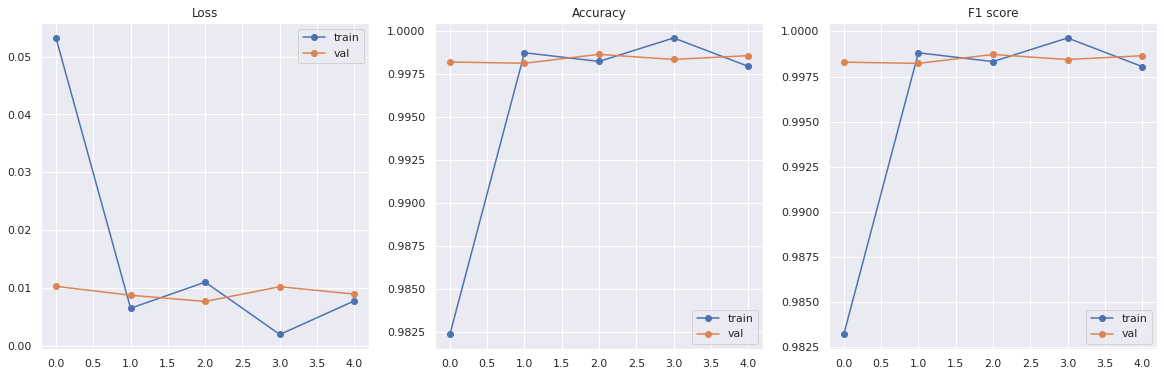

In [41]:
plot_history(history_rnn)

We see that the model reached a very nice result even after the first epoch of training, and shows to be impacted by very little to almost no overfitting.

#### Evaluate RNN model

Evaluate RNN based model on text test dataset.

In [42]:
loss_rnn, accuracy_rnn, precision_rnn, recall_rnn = rnn_model.evaluate(val_text_dataset)

421/421 [==============================] - 32s 77ms/step - loss: 0.0090 - accuracy: 0.9986 - precision: 0.9982 - recall: 0.9991


In [43]:
f1_rnn = 2*precision_rnn*recall_rnn/(precision_rnn + recall_rnn)

print("Performance metrics of the RNN classification model")
print("accuracy: ", accuracy_rnn)
print("precision: ", precision_rnn)
print("recall: ", recall_rnn)
print("F1 score: ", f1_rnn)

Performance metrics of the RNN classification model
accuracy:  0.9985894560813904
precision:  0.9981565475463867
recall:  0.9991483092308044
F1 score:  0.9986521821589739


### 5.3. Finetuning BERT

Tranformer models are the state of the art deep networks widely successful for language modeling tasks. BERT is a bidirectional Transformer encoder network developed by _Google research lab_ for various NLP tasks. There exists many variants of pretrained BERT models available in different libraries.

For this exercise we are going to use a small version of the BERT architecture which, have the same general architecture but fewer and/or smaller Transformer blocks. We pick the model from Tensorflow hub available at https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/1

Sources followed for this part of exercise is [tensorflow text classification with BERT tutorial](https://www.tensorflow.org/text/tutorials/classify_text_with_bert)

In [44]:
# Load pretrained BERT classification model
bert_model_path_tf_hub = 'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/1'

#### Model details

At the input we use BERT text preprocessing layer, which is followed by the BERT encoder model. The output of the encoder is classified in the classification layer using _sigmoid_ activation function. We fine tune the network using binary crossentropy loss and Adam optimizer with learning rate _0.00001_.

In [45]:
def get_bert_model():
    text_input = layers.Input(shape=(), dtype=tf.string, name='text_input')
    preprocessing_layer = hub.KerasLayer(bert_preprocess_path_tf_hub, name='preprocessing')
    encoder_inputs = preprocessing_layer(text_input)
    
    encoder = hub.KerasLayer(bert_model_path_tf_hub, trainable=True, name='BERT_encoder')
    outputs = encoder(encoder_inputs)
    
    y_net = outputs['pooled_output']
    y_net = layers.Dropout(0.1)(y_net)
    y_net = layers.Dense(1, activation='sigmoid', name='classifier')(y_net)
    
    return tf.keras.Model(text_input, y_net)


bert_model = get_bert_model()
bert_model.compile(loss="binary_crossentropy",
                  metrics=[
                        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
                        tf.keras.metrics.Precision(name="precision"),
                        tf.keras.metrics.Recall(name="recall"),
                    ], 
                  optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5))

bert_model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 text_input (InputLayer)        [(None,)]            0           []                               
                                                                                                  
 preprocessing (KerasLayer)     {'input_type_ids':   0           ['text_input[0][0]']             
                                (None, 128),                                                      
                                 'input_word_ids':                                                
                                (None, 128),                                                      
                                 'input_mask': (Non                                               
                                e, 128)}                                                      

#### BERT model training

Train the BERT based classifier for _5_ epochs.

In [46]:
print(f'Training BERT model with {bert_model_path_tf_hub}')
history_bert = bert_model.fit(train_text_dataset, validation_data=val_text_dataset, epochs=5)

Training BERT model with https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/1
Epoch 1/5
983/983 [==============================] - 509s 511ms/step - loss: 0.0313 - accuracy: 0.9889 - precision: 0.9886 - recall: 0.9902 - val_loss: 0.0059 - val_accuracy: 0.9983 - val_precision: 0.9991 - val_recall: 0.9976
Epoch 2/5
983/983 [==============================] - 498s 507ms/step - loss: 0.0028 - accuracy: 0.9995 - precision: 0.9991 - recall: 0.9998 - val_loss: 0.0027 - val_accuracy: 0.9996 - val_precision: 0.9993 - val_recall: 0.9999
Epoch 3/5
983/983 [==============================] - 495s 504ms/step - loss: 0.0017 - accuracy: 0.9996 - precision: 0.9993 - recall: 0.9998 - val_loss: 0.0024 - val_accuracy: 0.9995 - val_precision: 0.9993 - val_recall: 0.9997
Epoch 4/5
983/983 [==============================] - 497s 505ms/step - loss: 5.6030e-04 - accuracy: 0.9998 - precision: 0.9997 - recall: 1.0000 - val_loss: 0.0032 - val_accuracy: 0.9993 - val_precision: 0.9993 - val_recall

#### Plot history of BERT model training

Same as before, we plot the loss, accuracy and F1 score of the model as performance measure at every epoch for both training and validation set, in order to analyse model behavior.

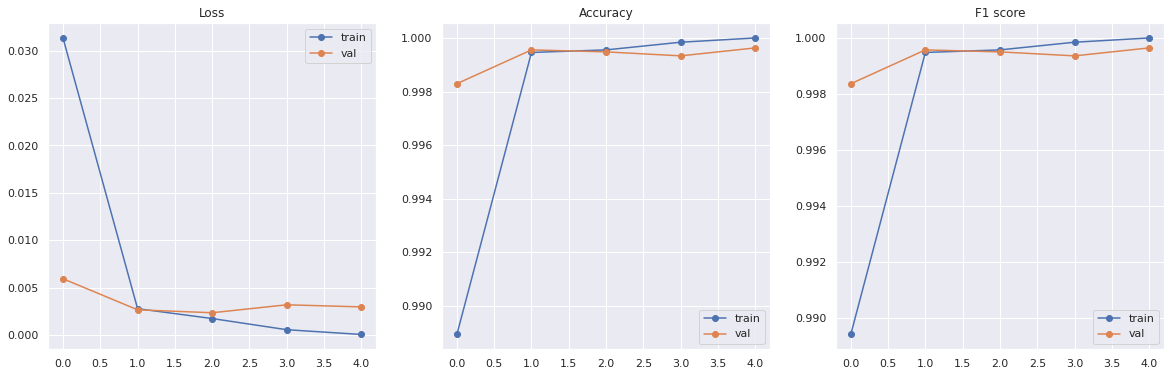

In [47]:
plot_history(history_bert)

The fine tuned BERT based model has performed extremely well as shown by the plots, and the validation performance is almost as same training performance metrics showing almost no overfitting.

#### Evaluate BERT model

Evaluate BERT based model on text test dataset.

In [48]:
loss_bert, accuracy_bert, precision_bert, recall_bert = bert_model.evaluate(val_text_dataset)

421/421 [==============================] - 95s 226ms/step - loss: 0.0030 - accuracy: 0.9996 - precision: 0.9993 - recall: 1.0000


In [49]:
f1_bert = 2*precision_bert*recall_bert/(precision_bert + recall_bert)

print("Performance metrics of fine tuned BERT classification model")
print("accuracy: ", accuracy_bert)
print("precision: ", precision_bert)
print("recall: ", recall_bert)
print("F1 score: ", f1_bert)

Performance metrics of fine tuned BERT classification model
accuracy:  0.9996287822723389
precision:  0.9992907643318176
recall:  1.0
F1 score:  0.9996452563674902


## 5. Compare model performances

We have trained 3 classification models, i.e. Multinomial Naive Bias, RNN and BERT model and now we can compare their evaluation results for performance analysis.

In [50]:
metrics = ['accuracy', 'precision', 'recall', 'F1 score']

# evaluation data
eval_data = {
    'Multinomial_NB': [acc_mnb, precision_mnb, recall_mnb, f1_mnb],
    'RNN': [accuracy_rnn, precision_rnn, recall_rnn, f1_rnn],
    'BERT': [accuracy_bert, precision_bert, recall_bert, f1_bert]
}

eval_df = pd.DataFrame(eval_data, index=metrics)
eval_df

,Multinomial_NB,RNN,BERT
accuracy,0.929918,0.998589,0.999629
precision,0.928261,0.998157,0.999291
recall,0.938538,0.999148,1.000000
F1 score,0.933371,0.998652,0.999645


**Observation:** Looking at the performance results, we can tell that both the RNN and BERT model performed almost perfectly well, even though BERT performed marginally better than the RNN across all the performance metric. This is as per theexpectation as the BERT model is much bigger in size with way more parameters and also pretrained. Also, Multinomial Naive Bias model performed nice enough considering its low complexity and computation cost.

### Analysis of ROC curve

In order to further analyse model performance, we can use ROC curve where we plot of False Positive Rate vs. True Positive Rate. As our dataset is balanced by both the classes ROC analysis can provide good insight.

Multinomial NB AUC=0.979827092647875
RNN AUC=0.9996690093976189
BERT AUC=0.9999836404658216


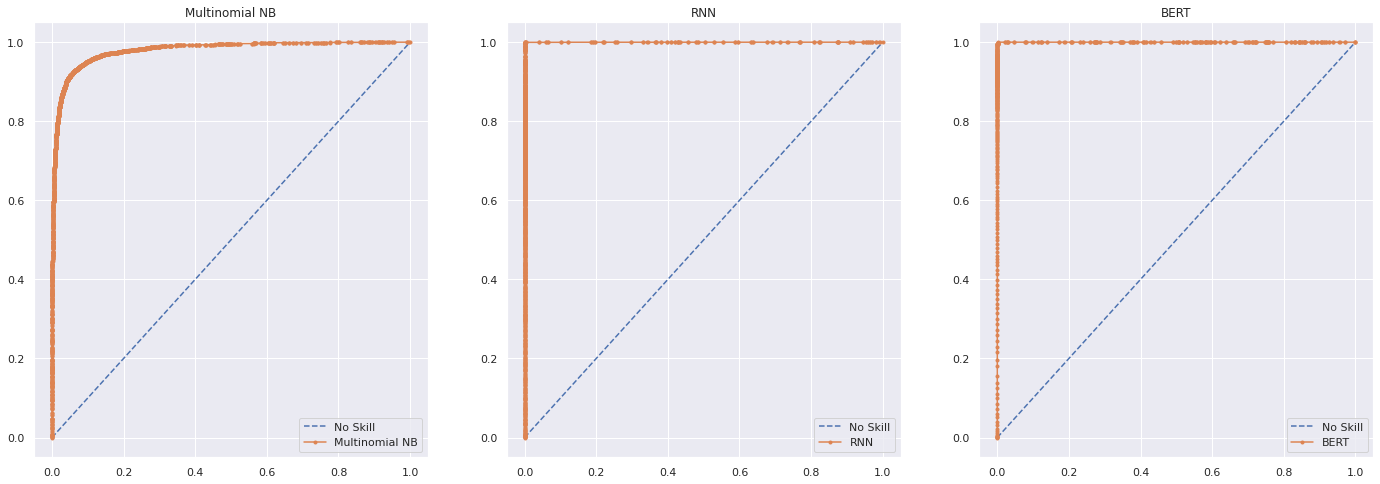

In [51]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24,8))

# keep probabilities for the positive outcome only
probs_nb = mnb_clf.predict_proba(X_tfidf_test)[:, 1]
probs_rnn = rnn_model.predict(X_text_test).ravel()
probs_bert = bert_model.predict(X_text_test).ravel()
probs_ns = np.zeros(y_text_test.shape[0])

# calculate roc curves
fpr_nb, tpr_nb, _ = roc_curve(y_tfidf_test, probs_nb)
fpr_rnn, tpr_rnn, _ = roc_curve(y_text_test, probs_rnn)
fpr_bert, tpr_bert, _ = roc_curve(y_text_test, probs_bert)
fpr_ns, tpr_ns, _ = roc_curve(y_text_test, probs_ns)

# calculate scores
auc_nb = roc_auc_score(y_tfidf_test, probs_nb)
auc_rnn = roc_auc_score(y_text_test, probs_rnn)
auc_bert = roc_auc_score(y_text_test, probs_bert)

print(f'Multinomial NB AUC={auc_nb}')
print(f'RNN AUC={auc_rnn}')
print(f'BERT AUC={auc_bert}')

# Plots
ax1.set_title('Multinomial NB')
ax1.plot(fpr_ns, tpr_ns, linestyle='--', label='No Skill')
ax1.plot(fpr_nb, tpr_nb, marker='.', label='Multinomial NB')
ax1.legend()

# plot accuracy during training
ax2.set_title('RNN')
ax2.plot(fpr_ns, tpr_ns, linestyle='--', label='No Skill')
ax2.plot(fpr_rnn, tpr_rnn, marker='.', label='RNN')
ax2.legend()

# plot F1 during training
ax3.set_title('BERT')
ax3.plot(fpr_ns, tpr_ns, linestyle='--', label='No Skill')
ax3.plot(fpr_bert, tpr_bert, marker='.', label='BERT')
ax3.legend()

plt.show()

The observation in the previous step is also reflected in the ROC, AOC analysis, where both the RNN and BERT model produced almost perfectly results, with Multinomial Naive Bias model also considerably well.

## 6. Summary

We have trained 3 sets of models, i.e. *Multinomial Naive Bias*, *RNN* and finetuned *BERT* for the classification tasks. The idea was to develop a baseline text embedding and classifier, based on which we could further develop advanced networks. We used TF-IDF vector model as the baseline text vector encoding, using which Multinomial NB was trained. Multinomial NB is known for its low complexity, easy trainability but high efficiency on feature related to word counts, which motivated us to choose it as our first model.

Next we wanted to develop a learnable word embedding from scratch and also train a model from scratch to compare with our baseline. The idea here was to learn from the text sequence for the classification task which required a sequence model. This was the reason for choosing LSTM network, which is traditionally used for similar NLP tasks. Using the LSTM based network we achieved nearly perfect result after training for *5* epochs.

Finally, we wanted to use a pretrained state-of-the-art model in order to analyze, whether it can better the performance of our custom model by any means. This was the motivation behind fine tuning the BERT model. The fine tuned BERT produced the best result by all means which is expected due to its huge size, complexity and pretraining on highly generalized datasets.

**Conclusion:** Even though the BERT produced the best result, for this dataset we would prefer to pick the **RNN model** due to its significantly low complexity and faster training time. As the RNN produced an almost similar performance, it is a good trade off for the computational reasons.